<a target="_blank" href="https://colab.research.google.com/github/AI4Finance-Foundation/FinRL-Tutorials/blob/master/2-Advance/FinRL_Ensemble_StockTrading_ICAIF_2020.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Deep Reinforcement Learning for Stock Trading from Scratch: Multiple StockÂ Trading Using Ensemble Strategy

Tutorials to use OpenAI DRL to trade multiple stocks using ensemble strategy in one Jupyter Notebook | Presented at ICAIF 2020

* This notebook is the reimplementation of our paper: Deep Reinforcement Learning for Automated Stock Trading: An Ensemble Strategy, using FinRL.
* Check out medium blog for detailed explanations: https://medium.com/@ai4finance/deep-reinforcement-learning-for-automated-stock-trading-f1dad0126a02
* Please report any issues to our Github: https://github.com/AI4Finance-LLC/FinRL-Library/issues
* **Pytorch Version**



# Content

* [1. Problem Definition](#0)
* [2. Getting Started - Load Python packages](#1)
    * [2.1. Install Packages](#1.1)    
    * [2.2. Check Additional Packages](#1.2)
    * [2.3. Import Packages](#1.3)
    * [2.4. Create Folders](#1.4)
* [3. Download Data](#2)
* [4. Preprocess Data](#3)        
    * [4.1. Technical Indicators](#3.1)
    * [4.2. Perform Feature Engineering](#3.2)
* [5.Build Environment](#4)  
    * [5.1. Training & Trade Data Split](#4.1)
    * [5.2. User-defined Environment](#4.2)   
    * [5.3. Initialize Environment](#4.3)    
* [6.Implement DRL Algorithms](#5)  
* [7.Backtesting Performance](#6)  
    * [7.1. BackTestStats](#6.1)
    * [7.2. BackTestPlot](#6.2)   
    * [7.3. Baseline Stats](#6.3)   
    * [7.3. Compare to Stock Market Index](#6.4)             

<a id='0'></a>
# Part 1. Problem Definition

This problem is to design an automated trading solution for single stock trading. We model the stock trading process as a Markov Decision Process (MDP). We then formulate our trading goal as a maximization problem.

The algorithm is trained using Deep Reinforcement Learning (DRL) algorithms and the components of the reinforcement learning environment are:


* Action: The action space describes the allowed actions that the agent interacts with the
environment. Normally, a âˆˆ A includes three actions: a âˆˆ {âˆ’1, 0, 1}, where âˆ’1, 0, 1 represent
selling, holding, and buying one stock. Also, an action can be carried upon multiple shares. We use
an action space {âˆ’k, ..., âˆ’1, 0, 1, ..., k}, where k denotes the number of shares. For example, "Buy
10 shares of AAPL" or "Sell 10 shares of AAPL" are 10 or âˆ’10, respectively

* Reward function: r(s, a, sâ€²) is the incentive mechanism for an agent to learn a better action. The change of the portfolio value when action a is taken at state s and arriving at new state s',  i.e., r(s, a, sâ€²) = vâ€² âˆ’ v, where vâ€² and v represent the portfolio
values at state sâ€² and s, respectively

* State: The state space describes the observations that the agent receives from the environment. Just as a human trader needs to analyze various information before executing a trade, so
our trading agent observes many different features to better learn in an interactive environment.

* Environment: Dow 30 consituents


The data of the single stock that we will be using for this case study is obtained from Yahoo Finance API. The data contains Open-High-Low-Close price and volume.


<a id='1'></a>
# Part 2. Getting Started- Load Python Packages

<a id='1.1'></a>
## 2.1. Install all the packages through FinRL library


In [1]:
# ## install finrl library
# !pip install wrds
# !pip install swig
# !pip install -q condacolab
# import condacolab
# condacolab.install()
# !apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git


  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /tmp/pip-req-build-6ujpyy3f
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /tmp/pip-req-build-6ujpyy3f
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit f4283de63ca73c915321c5555fa3751698a61eec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /tmp/pip-install-lq_g8vmw/elegantrl_f9ba0150a8c84c96bfbd6ea83ea4c50f
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /tmp/pip-install-lq_g8vmw/elegantrl_f9ba0150a8c84c96bfbd6ea83ea4c50f
  Resolved https://github.com/AI4Finance-Foundation/ElegantRL.git to commit 24228304867bdc80165de435a598ef90b1893598
  Preparing metadata (setup.py) ... done



<a id='1.2'></a>
## 2.2. Check if the additional packages needed are present, if not install them.
* Yahoo Finance API
* pandas
* numpy
* matplotlib
* stockstats
* OpenAI gym
* stable-baselines
* tensorflow
* pyfolio

<a id='1.3'></a>
## 2.3. Import Packages

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "drive/MyDrive/GoogleColab/math7120"

mkdir: cannot create directory ‘math7120’: File exists
/content/drive/MyDrive/GoogleColab/math7120


In [42]:
import warnings
warnings.filterwarnings("ignore")

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import time

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLEnsembleAgent
from finrl.plot import backtest_stats, get_baseline
from finrl.main import check_and_make_directories
from finrl.config_tickers import DOW_30_TICKER
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
)
from stable_baselines3.common.vec_env import DummyVecEnv

import sys
sys.path.append("../FinRL-Library")

%matplotlib inline

In [44]:
TRAIN_START_DATE = "2012-03-01"
TRAIN_END_DATE = "2022-02-28"

TEST_START_DATE = "2022-03-01"
TEST_END_DATE = "2024-02-29"

TRADE_START_DATE = "2024-03-01"
TRADE_END_DATE = "2026-03-01"

In [45]:
# ============================================================================
# Data Classes and Grid Search Framework for Hyperparameter Tuning
# ============================================================================

from dataclasses import dataclass, field
from typing import List, Iterator, Optional, Callable, Dict, Any, Tuple
from abc import ABC, abstractmethod
from enum import Enum
import itertools


class WeightingScheme(Enum):
    """Weighting schemes for ensemble model combination (phi in paper)."""
    IMSE = "imse"      # Inverse Mean Squared Error: phi(x) = 1/MSE
    IMAE = "imae"      # Inverse Mean Absolute Error: phi(x) = 1/MAE
    SOFTMAX = "softmax" # Softmax weighting: phi(x) = exp(-x)/sum(exp(-x))


@dataclass
class EnsembleHyperparameters:
    """Hyperparameters for the Bayesian ensemble weighting scheme.
    
    Based on paper formulas:
    - Raw weight: w_hat_{i_M}(t) = sum_{i=t-1}^{t-e_w} phi(gamma^i * error_i)
    - Final weight: w_{i_M}(t) = l * w_{i_M}(t-1) + (1-l) * w_hat_{i_M}(t)
    
    Parameters
    ----------
    i_c : int
        Cold-start index. During first i_c timesteps, use single best model.
    e_w : int
        Evaluation window for weight calculation (lookback in days).
    phi : WeightingScheme
        Weighting scheme (IMSE, IMAE, or SOFTMAX).
    gamma : float
        Discount factor for emphasizing recent observations (0 < gamma <= 1).
    l : float
        Update parameter (lambda) for balancing historical vs current weights.
        Higher l = more weight on historical, lower l = more adaptive.
    """
    i_c: int = 1              # Cold-start iterations
    e_w: int = 21             # Evaluation window (days)
    phi: WeightingScheme = WeightingScheme.IMSE
    gamma: float = 0.95       # Discount factor
    l: float = 0.5            # Update parameter (lambda)

    def to_dict(self) -> dict:
        return {
            "i_c": self.i_c,
            "e_w": self.e_w,
            "phi": self.phi.value,
            "gamma": self.gamma,
            "l": self.l
        }
    
    @classmethod
    def from_dict(cls, d: dict) -> "EnsembleHyperparameters":
        phi = WeightingScheme(d.get("phi", "imse"))
        return cls(
            i_c=d.get("i_c", 1),
            e_w=d.get("e_w", 21),
            phi=phi,
            gamma=d.get("gamma", 0.95),
            l=d.get("l", 0.5),
        )
    
    def __repr__(self):
        return f"EnsembleHyperparameters(i_c={self.i_c}, e_w={self.e_w}, phi={self.phi.value}, gamma={self.gamma}, l={self.l})"


@dataclass
class HyperparameterGrid:
    """Generates parameter combinations for grid search.
    
    Example
    -------
    >>> grid = HyperparameterGrid(
    ...     i_c_values=[1, 2],
    ...     gamma_values=[0.9, 0.95]
    ... )
    >>> for params in grid:
    ...     print(params.to_dict())
    """
    i_c_values: List[int] = field(default_factory=lambda: [1, 2, 3])
    e_w_values: List[int] = field(default_factory=lambda: [10, 21, 42])
    phi_values: List[WeightingScheme] = field(default_factory=lambda: list(WeightingScheme))
    gamma_values: List[float] = field(default_factory=lambda: [0.9, 0.95, 0.99])
    l_values: List[float] = field(default_factory=lambda: [0.3, 0.5, 0.7])

    def __iter__(self) -> Iterator[EnsembleHyperparameters]:
        """Yield all combinations of hyperparameters."""
        for combo in itertools.product(
            self.i_c_values,
            self.e_w_values,
            self.phi_values,
            self.gamma_values,
            self.l_values
        ):
            yield EnsembleHyperparameters(
                i_c=combo[0],
                e_w=combo[1],
                phi=combo[2],
                gamma=combo[3],
                l=combo[4]
            )

    def __len__(self) -> int:
        return (
            len(self.i_c_values) *
            len(self.e_w_values) *
            len(self.phi_values) *
            len(self.gamma_values) *
            len(self.l_values)
        )


@dataclass
class SearchResult:
    """Result from evaluating a hyperparameter configuration."""
    params: EnsembleHyperparameters
    score: float  # Primary metric (Sharpe ratio)
    metrics: dict  # Additional metrics (total_return, max_drawdown, etc.)
    
    def __repr__(self):
        return f"SearchResult(score={self.score:.4f}, params={self.params.to_dict()})"


# ============================================================================
# Grid Search Classes
# ============================================================================

class BaseGridSearch(ABC):
    """Abstract base class for hyperparameter search strategies."""

    @abstractmethod
    def search(
        self,
        objective_fn: Callable[[EnsembleHyperparameters], SearchResult],
        param_grid: HyperparameterGrid,
        n_trials: Optional[int] = None,
    ) -> List[SearchResult]:
        """Run the search and return all results sorted by score (descending)."""
        pass

    @abstractmethod
    def get_best(self) -> Optional[SearchResult]:
        """Return the best result found."""
        pass
    
    @abstractmethod
    def get_results_df(self) -> pd.DataFrame:
        """Return all results as a DataFrame."""
        pass


class StandardGridSearch(BaseGridSearch):
    """Exhaustive grid search over all parameter combinations."""

    def __init__(self, verbose: bool = True):
        self.verbose = verbose
        self._results: List[SearchResult] = []

    def search(
        self,
        objective_fn: Callable[[EnsembleHyperparameters], SearchResult],
        param_grid: HyperparameterGrid,
        n_trials: Optional[int] = None,  # Ignored for exhaustive search
    ) -> List[SearchResult]:
        """Exhaustively evaluate all parameter combinations."""
        self._results = []
        total = len(param_grid)
        
        print(f"Starting exhaustive grid search over {total} combinations...")
        
        for idx, params in enumerate(param_grid):
            if self.verbose:
                print(f"[{idx+1}/{total}] Evaluating {params.to_dict()}")
            
            try:
                result = objective_fn(params)
                self._results.append(result)
                if self.verbose:
                    print(f"  -> Sharpe: {result.score:.4f}")
            except Exception as e:
                print(f"  -> FAILED: {e}")
        
        # Sort by score descending
        self._results.sort(key=lambda r: r.score, reverse=True)
        
        print(f"\nGrid search complete. Best Sharpe: {self._results[0].score:.4f}")
        return self._results

    def get_best(self) -> Optional[SearchResult]:
        return self._results[0] if self._results else None
    
    def get_results_df(self) -> pd.DataFrame:
        """Return all results as a DataFrame for analysis."""
        if not self._results:
            return pd.DataFrame()
        
        data = []
        for r in self._results:
            row = r.params.to_dict()
            row["sharpe"] = r.score
            row.update(r.metrics)
            data.append(row)
        return pd.DataFrame(data)


class BayesianOptimizationSearch(BaseGridSearch):
    """Bayesian optimization search using Optuna (placeholder for future implementation)."""

    def __init__(
        self,
        sampler: str = "tpe",  # Tree-Parzen Estimator
        n_startup_trials: int = 10,
        verbose: bool = True,
    ):
        self.sampler = sampler
        self.n_startup_trials = n_startup_trials
        self.verbose = verbose
        self._results: List[SearchResult] = []

    def search(
        self,
        objective_fn: Callable[[EnsembleHyperparameters], SearchResult],
        param_grid: HyperparameterGrid,
        n_trials: Optional[int] = 50,
    ) -> List[SearchResult]:
        """Use Optuna for Bayesian optimization with Tree-Parzen Estimator sampler."""
        import optuna
        from optuna.samplers import TPESampler
        from optuna.pruners import HyperbandPruner
        
        self._results = []
        
        # Create a dict mapping to track trial results
        trial_results = {}
        
        def optuna_objective(trial: optuna.Trial) -> float:
            """Optuna objective function that wraps the ensemble objective."""
            # Sample hyperparameters from the parameter space
            i_c = trial.suggest_int("i_c", min(param_grid.i_c_values), max(param_grid.i_c_values))
            e_w = trial.suggest_int("e_w", min(param_grid.e_w_values), max(param_grid.e_w_values))
            phi_idx = trial.suggest_int("phi_idx", 0, len(param_grid.phi_values) - 1)
            gamma = trial.suggest_float("gamma", min(param_grid.gamma_values), max(param_grid.gamma_values))
            l = trial.suggest_float("l", min(param_grid.l_values), max(param_grid.l_values))
            
            phi = param_grid.phi_values[phi_idx]
            
            # Create hyperparameter object
            params = EnsembleHyperparameters(
                i_c=i_c,
                e_w=e_w,
                phi=phi,
                gamma=gamma,
                l=l,
            )
            
            try:
                # Evaluate with the objective function
                result = objective_fn(params)
                
                # Store result
                trial_results[trial.number] = result
                
                if self.verbose:
                    print(f"[Trial {trial.number}] Sharpe: {result.score:.4f} | {params.to_dict()}")
                
                return result.score  # Optuna maximizes this
            except Exception as e:
                if self.verbose:
                    print(f"[Trial {trial.number}] FAILED: {e}")
                # Return worst possible score
                return float('-inf')
        
        # Create study with TPE sampler and Hyperband pruner
        sampler = TPESampler(n_startup_trials=self.n_startup_trials, seed=42)
        pruner = HyperbandPruner()
        
        study = optuna.create_study(
            study_name="ensemble_bayesian_opt",
            direction="maximize",
            sampler=sampler,
            pruner=pruner,
        )
        
        if self.verbose:
            print(f"\nStarting Bayesian optimization with {n_trials} trials...")
            print(f"Sampler: {self.sampler.upper()}, Startup trials: {self.n_startup_trials}\n")
        
        # Run optimization
        study.optimize(
            optuna_objective,
            n_trials=n_trials,
            catch=(ValueError, RuntimeError),
        )
        
        # Extract results from trial_results dict
        self._results = []
        for trial in study.trials:
            if trial.number in trial_results:
                self._results.append(trial_results[trial.number])
        
        # Sort by score descending
        self._results.sort(key=lambda r: r.score, reverse=True)
        
        if self.verbose:
            print(f"\nBayesian optimization complete.")
            if self._results:
                print(f"Best Sharpe Ratio: {self._results[0].score:.4f}")
                print(f"Best Parameters: {self._results[0].params.to_dict()}")
        
        return self._results

    def get_best(self) -> Optional[SearchResult]:
        return self._results[0] if self._results else None
    
    def get_results_df(self) -> pd.DataFrame:
        if not self._results:
            return pd.DataFrame()
        data = []
        for r in self._results:
            row = r.params.to_dict()
            row["sharpe"] = r.score
            row.update(r.metrics)
            data.append(row)
        return pd.DataFrame(data)


print("Data classes and grid search framework loaded successfully!")

Data classes and grid search framework loaded successfully!


In [46]:
# ============================================================================
# Bayesian Ensemble Agent Implementation with Hyperparameter Grid Search
# ============================================================================

from finrl.agents.stablebaselines3.models import MODELS
from finrl.agents.stablebaselines3.models import (
    MODEL_KWARGS,
    NOISE,
    TensorboardCallback,
)
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
from finrl import config
import statistics


class FixedTensorboardCallback(BaseCallback):
    """Fixed TensorboardCallback that handles both on-policy (rollout_buffer)
    and off-policy (replay_buffer) algorithms."""

    def __init__(self, verbose=0):
        super().__init__(verbose)

    def _on_step(self) -> bool:
        try:
            self.logger.record(key="train/reward", value=self.locals["rewards"][0])
        except BaseException:
            try:
                self.logger.record(key="train/reward", value=self.locals["reward"][0])
            except BaseException:
                self.logger.record(key="train/reward", value=None)
        return True

    def _on_rollout_end(self) -> bool:
        try:
            if "rollout_buffer" in self.locals:
                rewards = self.locals["rollout_buffer"].rewards.flatten()
            elif "replay_buffer" in self.locals:
                replay_buf = self.locals["replay_buffer"]
                if replay_buf.full:
                    rewards = replay_buf.rewards[:replay_buf.buffer_size].flatten()
                else:
                    rewards = replay_buf.rewards[:replay_buf.pos].flatten()
            else:
                rewards = None

            if rewards is not None and len(rewards) > 0:
                self.logger.record(key="train/reward_min", value=min(rewards))
                self.logger.record(key="train/reward_mean", value=statistics.mean(rewards))
                self.logger.record(key="train/reward_max", value=max(rewards))
            else:
                self.logger.record(key="train/reward_min", value=None)
                self.logger.record(key="train/reward_mean", value=None)
                self.logger.record(key="train/reward_max", value=None)
        except BaseException:
            self.logger.record(key="train/reward_min", value=None)
            self.logger.record(key="train/reward_mean", value=None)
            self.logger.record(key="train/reward_max", value=None)
        return True


class DRLEnsembleAgentBayesian:
    """Bayesian Ensemble Agent with Train-Once and Hyperparameter Grid Search.
    
    This implementation follows the paper formulas for dynamic model weighting:
    - Raw weight: w_hat_{i_M}(t) = sum phi(gamma^i * (y_hat - y)) / sum over models
    - Final weight: w(t) = l * w(t-1) + (1-l) * w_hat(t)
    
    New Workflow:
    1. train_models() - Train all RL models ONCE on training period
    2. collect_model_predictions() - Get per-timestep returns on validation period  
    3. compute_expert_actions() - Compute target returns from price changes
    4. evaluate_hyperparameters() - Score one hyperparameter configuration
    5. run_hyperparameter_search() - Find optimal params via grid search
    6. get_best_parameters() - Retrieve optimal hyperparameters
    7. run_ensemble_with_params() - Execute ensemble with specified params
    """

    # ------------------------------------------------------------------ #
    # Static helpers (from DRLEnsembleAgent)
    # ------------------------------------------------------------------ #

    @staticmethod
    def get_model(
        model_name,
        env,
        policy="MlpPolicy",
        policy_kwargs=None,
        model_kwargs=None,
        seed=None,
        verbose=1,
    ):
        if model_name not in MODELS:
            raise ValueError(f"Model '{model_name}' not found in MODELS.")

        if model_kwargs is None:
            temp_model_kwargs = MODEL_KWARGS[model_name]
        else:
            temp_model_kwargs = model_kwargs.copy()

        if "action_noise" in temp_model_kwargs:
            n_actions = env.action_space.shape[-1]
            temp_model_kwargs["action_noise"] = NOISE[
                temp_model_kwargs["action_noise"]
            ](mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
        
        return MODELS[model_name](
            policy=policy,
            env=env,
            tensorboard_log=f"{config.TENSORBOARD_LOG_DIR}/{model_name}",
            verbose=verbose,
            policy_kwargs=policy_kwargs,
            seed=seed,
            **temp_model_kwargs,
        )

    @staticmethod
    def train_model(
        model,
        model_name,
        tb_log_name,
        iter_num,
        total_timesteps=5000,
        callbacks=None,
    ):
        model = model.learn(
            total_timesteps=total_timesteps,
            tb_log_name=tb_log_name,
            callback=(
                CallbackList(
                    [FixedTensorboardCallback()]
                    + [callback for callback in callbacks]
                )
                if callbacks is not None
                else FixedTensorboardCallback()
            ),
        )
        model.save(
            f"{config.TRAINED_MODEL_DIR}/{model_name.upper()}_{total_timesteps // 1000}k_{iter_num}"
        )
        return model

    # ------------------------------------------------------------------ #
    # Constructor
    # ------------------------------------------------------------------ #

    def __init__(
        self,
        df: pd.DataFrame,
        train_period: Tuple[str, str],
        validation_period: Tuple[str, str],
        stock_dim: int,
        hmax: int,
        initial_amount: float,
        buy_cost_pct: float,
        sell_cost_pct: float,
        reward_scaling: float,
        state_space: int,
        action_space: int,
        tech_indicator_list: List[str],
        print_verbosity: int = 10,
        n_m: int = 5,
    ):
        """Initialize the Bayesian Ensemble Agent.
        
        Parameters
        ----------
        df : pd.DataFrame
            Full dataset with columns: date, tic, close, and technical indicators.
        train_period : tuple
            (start_date, end_date) for training.
        validation_period : tuple
            (start_date, end_date) for validation/hyperparameter tuning.
        n_m : int
            Maximum number of models to include in ensemble.
        """
        self.df = df
        self.train_period = train_period
        self.validation_period = validation_period
        
        # Extract unique dates for each period
        self.train_dates = df[
            (df.date >= train_period[0]) & (df.date <= train_period[1])
        ].date.unique()
        self.validation_dates = df[
            (df.date >= validation_period[0]) & (df.date <= validation_period[1])
        ].date.unique()
        
        # Trading environment parameters
        self.stock_dim = stock_dim
        self.hmax = hmax
        self.initial_amount = initial_amount
        self.buy_cost_pct = buy_cost_pct
        self.sell_cost_pct = sell_cost_pct
        self.reward_scaling = reward_scaling
        self.state_space = state_space
        self.action_space = action_space
        self.tech_indicator_list = tech_indicator_list
        self.print_verbosity = print_verbosity
        self.n_m = n_m
        
        # Storage for trained models and predictions
        self._trained_models: Dict[str, Any] = {}
        self._validation_predictions: Dict[str, pd.DataFrame] = {}
        self._expert_actions: Optional[pd.DataFrame] = None
        self._best_params: Optional[EnsembleHyperparameters] = None
        
        print(f"Initialized DRLEnsembleAgentBayesian")
        print(f"  Training period: {train_period[0]} to {train_period[1]} ({len(self.train_dates)} days)")
        print(f"  Validation period: {validation_period[0]} to {validation_period[1]} ({len(self.validation_dates)} days)")
        print(f"  Stock dimension: {stock_dim}")

    # ------------------------------------------------------------------ #
    # Step 1: Train Models (ONCE)
    # ------------------------------------------------------------------ #
    
    def train_models(
        self,
        model_kwargs: Dict[str, dict],
        timesteps_dict: Dict[str, int],
        save_path: Optional[str] = None,
    ) -> Dict[str, Any]:
        """Train all RL models ONCE on the full training period.
        
        Parameters
        ----------
        model_kwargs : dict
            {model_name: model_kwargs} for each algorithm (a2c, ppo, ddpg, sac, td3).
        timesteps_dict : dict
            {model_name: total_timesteps} for training.
        save_path : str, optional
            Directory to save trained models.
        
        Returns
        -------
        dict
            {model_name: trained_model} dictionary.
        """
        train_data = data_split(
            self.df,
            start=self.train_period[0],
            end=self.train_period[1]
        )
        
        train_env = DummyVecEnv([
            lambda: StockTradingEnv(
                df=train_data,
                stock_dim=self.stock_dim,
                hmax=self.hmax,
                initial_amount=self.initial_amount,
                num_stock_shares=[0] * self.stock_dim,
                buy_cost_pct=[self.buy_cost_pct] * self.stock_dim,
                sell_cost_pct=[self.sell_cost_pct] * self.stock_dim,
                reward_scaling=self.reward_scaling,
                state_space=self.state_space,
                action_space=self.action_space,
                tech_indicator_list=self.tech_indicator_list,
                print_verbosity=self.print_verbosity,
            )
        ])

        print("=" * 60)
        print("TRAINING ALL MODELS (ONCE)")
        print("=" * 60)
        
        for model_name, kwargs in model_kwargs.items():
            if kwargs is None:
                print(f"Skipping {model_name} (no kwargs provided)")
                continue
                
            print(f"\n{'='*20} Training {model_name.upper()} {'='*20}")
            print(f"Timesteps: {timesteps_dict.get(model_name, 50000)}")
            
            model = self.get_model(
                model_name, train_env, policy="MlpPolicy", model_kwargs=kwargs
            )
            model = self.train_model(
                model,
                model_name,
                tb_log_name=f"{model_name}_full_train",
                iter_num=0,
                total_timesteps=timesteps_dict.get(model_name, 50000),
            )
            self._trained_models[model_name] = model
            
            if save_path:
                model.save(f"{save_path}/{model_name}_trained.zip")
                print(f"  Saved to {save_path}/{model_name}_trained.zip")
        
        print(f"\n{'='*60}")
        print(f"Training complete. {len(self._trained_models)} models trained.")
        print("=" * 60)
        
        return self._trained_models

    # ------------------------------------------------------------------ #
    # Step 2: Collect Model Predictions on Validation
    # ------------------------------------------------------------------ #
    
    def collect_model_predictions(self) -> Dict[str, pd.DataFrame]:
        """Run each trained model through validation period, collecting per-step returns.
        
        Returns
        -------
        dict
            {model_name: DataFrame with columns [date, portfolio_return]}.
        """
        if not self._trained_models:
            raise ValueError("No trained models. Call train_models() first.")
        
        validation_data = data_split(
            self.df,
            start=self.validation_period[0],
            end=self.validation_period[1],
        )
        
        print("=" * 60)
        print("COLLECTING MODEL PREDICTIONS ON VALIDATION SET")
        print("=" * 60)
        
        for model_name, model in self._trained_models.items():
            print(f"\nCollecting predictions for {model_name.upper()}...")
            
            # Create fresh validation environment
            val_env = DummyVecEnv([
                lambda: StockTradingEnv(
                    df=validation_data,
                    stock_dim=self.stock_dim,
                    hmax=self.hmax,
                    initial_amount=self.initial_amount,
                    num_stock_shares=[0] * self.stock_dim,
                    buy_cost_pct=[self.buy_cost_pct] * self.stock_dim,
                    sell_cost_pct=[self.sell_cost_pct] * self.stock_dim,
                    reward_scaling=self.reward_scaling,
                    state_space=self.state_space,
                    action_space=self.action_space,
                    tech_indicator_list=self.tech_indicator_list,
                    print_verbosity=self.print_verbosity,
                )
            ])
            
            obs = val_env.reset()
            predictions = []
            unique_dates = validation_data.date.unique()
            
            # Track portfolio values for return calculation
            prev_portfolio_value = self.initial_amount
            
            for i, date in enumerate(unique_dates[:-1]):
                action, _states = model.predict(obs, deterministic=True)
                obs, reward, done, info = val_env.step(action)
                
                # Get current portfolio value from environment
                env_unwrapped = val_env.envs[0]
                current_portfolio_value = env_unwrapped.state[0]  # Cash
                # Add stock values: prices * shares
                prices = np.array(env_unwrapped.state[1:self.stock_dim+1])
                shares = np.array(env_unwrapped.state[self.stock_dim+1:2*self.stock_dim+1])
                current_portfolio_value += np.dot(prices, shares)
                
                # Calculate daily return
                if prev_portfolio_value > 0:
                    portfolio_return = (current_portfolio_value - prev_portfolio_value) / prev_portfolio_value
                else:
                    portfolio_return = 0.0
                
                predictions.append({
                    "date": date,
                    "portfolio_return": portfolio_return,
                    "portfolio_value": current_portfolio_value,
                })
                
                prev_portfolio_value = current_portfolio_value
                
                if done[0]:
                    break
            
            self._validation_predictions[model_name] = pd.DataFrame(predictions)
            print(f"  Collected {len(predictions)} timesteps")
        
        print(f"\n{'='*60}")
        print(f"Prediction collection complete for {len(self._validation_predictions)} models.")
        print("=" * 60)
        
        return self._validation_predictions

    # ------------------------------------------------------------------ #
    # Step 3: Compute Expert Actions (Target Returns)
    # ------------------------------------------------------------------ #
    
    def compute_expert_actions(self, z: float = 2.0) -> pd.DataFrame:
        """Compute expert actions (target returns) based on price changes.
        
        Implements the paper formula:
            action_{i,t} = -exp(rho_{i,t} * z) / sum_j exp(|rho_{j,t} * z|)  if rho < 0
            action_{i,t} =  exp(rho_{i,t} * z) / sum_j exp(|rho_{j,t} * z|)  if rho >= 0
        
        where rho_{i,t} = percentage change in close price of stock i at step t
        
        Parameters
        ----------
        z : float
            Scaling factor for the exponential (paper suggests z in [1, 5]).
        
        Returns
        -------
        pd.DataFrame
            Expert actions with columns [date, target_return].
        """
        validation_data = data_split(
            self.df,
            start=self.validation_period[0],
            end=self.validation_period[1],
        )
        
        unique_dates = validation_data.date.unique()
        expert_actions = []
        
        print(f"Computing expert actions with z={z}...")
        
        for i in range(len(unique_dates) - 1):
            current_date = unique_dates[i]
            next_date = unique_dates[i + 1]
            
            # Get close prices for current and next day
            current_data = validation_data[validation_data.date == current_date].sort_values("tic")
            next_data = validation_data[validation_data.date == next_date].sort_values("tic")
            
            current_close = current_data["close"].values
            next_close = next_data["close"].values
            
            # Ensure alignment
            if len(current_close) != len(next_close) or len(current_close) == 0:
                continue
            
            # Compute percentage returns (rho)
            rho = (next_close - current_close) / (current_close + 1e-8)
            
            # Compute expert action per paper formula
            exp_terms = np.exp(np.abs(rho) * z)
            normalizer = np.sum(exp_terms) + 1e-8
            
            expert_action = np.where(
                rho >= 0,
                exp_terms / normalizer,
                -exp_terms / normalizer
            )
            
            # Target return is the weighted sum of individual returns
            target_return = np.dot(np.abs(expert_action), rho)
            
            expert_actions.append({
                "date": current_date,
                "target_return": target_return,
            })
        
        self._expert_actions = pd.DataFrame(expert_actions)
        print(f"Computed expert actions for {len(expert_actions)} timesteps.")
        
        return self._expert_actions

    # ------------------------------------------------------------------ #
    # Step 4: Evaluate Hyperparameters
    # ------------------------------------------------------------------ #
    
    def evaluate_hyperparameters(self, params: EnsembleHyperparameters) -> SearchResult:
        """Evaluate a single hyperparameter configuration on validation data.
        
        Implements the paper weighting formulas with the given hyperparameters.
        
        Parameters
        ----------
        params : EnsembleHyperparameters
            The hyperparameters to evaluate.
        
        Returns
        -------
        SearchResult
            Contains Sharpe ratio and other metrics.
        """
        if not self._validation_predictions or self._expert_actions is None:
            raise ValueError("Must call collect_model_predictions() and compute_expert_actions() first.")
        
        # Get aligned dates
        dates = self._expert_actions["date"].values
        n_dates = len(dates)
        
        # Initialize weights
        model_weights = {name: 0.0 for name in self._trained_models.keys()}
        
        # Track ensemble returns
        ensemble_returns = []
        
        for t in range(n_dates):
            current_date = dates[t]
            
            # Get expert (target) return for this timestep
            target_return = self._expert_actions[
                self._expert_actions.date == current_date
            ]["target_return"].values[0]
            
            # Compute model errors over evaluation window [t - e_w, t-1]
            window_start = max(0, t - params.e_w)
            model_errors = {}
            
            for model_name in self._trained_models.keys():
                model_preds = self._validation_predictions[model_name]
                
                # Get predictions in window
                window_dates = dates[window_start:t] if t > 0 else []
                
                if len(window_dates) == 0:
                    model_errors[model_name] = 1.0
                    continue
                
                window_preds = model_preds[model_preds.date.isin(window_dates)]
                window_targets = self._expert_actions[self._expert_actions.date.isin(window_dates)]
                
                if len(window_preds) == 0:
                    model_errors[model_name] = 1.0
                    continue
                
                # Merge predictions and targets
                merged = window_preds.merge(window_targets, on="date", how="inner")
                
                if len(merged) == 0:
                    model_errors[model_name] = 1.0
                    continue
                
                pred_returns = merged["portfolio_return"].values
                target_returns = merged["target_return"].values
                
                # Apply gamma discounting (more recent = higher weight)
                n = len(pred_returns)
                gamma_weights = np.array([params.gamma ** (n - 1 - i) for i in range(n)])
                
                errors = pred_returns - target_returns
                
                # Apply phi (weighting scheme) to compute weighted error
                if params.phi == WeightingScheme.IMSE:
                    weighted_error = np.sum(gamma_weights * errors ** 2) / (np.sum(gamma_weights) + 1e-8)
                elif params.phi == WeightingScheme.IMAE:
                    weighted_error = np.sum(gamma_weights * np.abs(errors)) / (np.sum(gamma_weights) + 1e-8)
                elif params.phi == WeightingScheme.SOFTMAX:
                    weighted_error = np.sum(gamma_weights * errors ** 2) / (np.sum(gamma_weights) + 1e-8)
                
                model_errors[model_name] = weighted_error + 1e-8
            
            # Compute raw weights (w_hat) from inverse error
            if t < params.i_c:
                # Cold start: use best model only
                best_model = min(model_errors, key=model_errors.get)
                w_hat = {name: 1.0 if name == best_model else 0.0 for name in model_errors}
            else:
                # Select top n_m models
                ranked = sorted(model_errors.items(), key=lambda x: x[1])[:self.n_m]
                selected = {name for name, _ in ranked}
                
                # Apply phi to compute w_hat
                if params.phi == WeightingScheme.SOFTMAX:
                    scores = {name: -err for name, err in model_errors.items() if name in selected}
                    if scores:
                        max_score = max(scores.values())
                        exp_scores = {name: np.exp(s - max_score) for name, s in scores.items()}
                        total_exp = sum(exp_scores.values()) + 1e-8
                        w_hat = {name: exp_scores.get(name, 0) / total_exp for name in model_errors}
                    else:
                        w_hat = {name: 1.0 / len(model_errors) for name in model_errors}
                else:
                    # IMSE or IMAE: inverse error
                    inv_errors = {name: 1.0 / err for name, err in model_errors.items() if name in selected}
                    total_inv = sum(inv_errors.values()) + 1e-8
                    w_hat = {name: inv_errors.get(name, 0) / total_inv for name in model_errors}
            
            # Update weights: w(t) = l * w(t-1) + (1-l) * w_hat(t)
            for name in model_weights:
                if t == 0:
                    model_weights[name] = w_hat.get(name, 0)
                else:
                    model_weights[name] = params.l * model_weights[name] + (1 - params.l) * w_hat.get(name, 0)
            
            # Normalize weights
            total_weight = sum(model_weights.values())
            if total_weight > 0:
                model_weights = {k: v / total_weight for k, v in model_weights.items()}
            
            # Compute ensemble return as weighted sum of model returns
            ensemble_return = 0.0
            for name in self._trained_models.keys():
                preds = self._validation_predictions[name]
                pred_row = preds[preds.date == current_date]
                if len(pred_row) > 0:
                    ensemble_return += model_weights[name] * pred_row["portfolio_return"].values[0]
            
            ensemble_returns.append(ensemble_return)
        
        # Compute performance metrics
        returns_array = np.array(ensemble_returns)
        
        if len(returns_array) > 0 and returns_array.std() > 1e-10:
            sharpe = (252 ** 0.5) * returns_array.mean() / returns_array.std()
        else:
            sharpe = 0.0
        
        # Compute additional metrics
        cumulative_return = np.prod(1 + returns_array) - 1 if len(returns_array) > 0 else 0.0
        max_drawdown = self._compute_max_drawdown(returns_array) if len(returns_array) > 0 else 0.0
        volatility = returns_array.std() * (252 ** 0.5) if len(returns_array) > 0 else 0.0
        
        return SearchResult(
            params=params,
            score=sharpe,
            metrics={
                "total_return": cumulative_return,
                "max_drawdown": max_drawdown,
                "volatility": volatility,
                "n_timesteps": len(returns_array),
            }
        )
    
    def _compute_max_drawdown(self, returns: np.ndarray) -> float:
        """Compute maximum drawdown from returns array."""
        if len(returns) == 0:
            return 0.0
        cumulative = np.cumprod(1 + returns)
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (running_max - cumulative) / (running_max + 1e-8)
        return drawdown.max()

    # ------------------------------------------------------------------ #
    # Step 5: Run Hyperparameter Search
    # ------------------------------------------------------------------ #
    
    def run_hyperparameter_search(
        self,
        grid_search: BaseGridSearch,
        param_grid: Optional[HyperparameterGrid] = None,
    ) -> SearchResult:
        """Run hyperparameter search using the provided strategy.
        
        Parameters
        ----------
        grid_search : BaseGridSearch
            Search strategy (StandardGridSearch or BayesianOptimizationSearch).
        param_grid : HyperparameterGrid, optional
            Parameter grid to search. Uses defaults if not provided.
        
        Returns
        -------
        SearchResult
            The best hyperparameter configuration found.
        """
        if param_grid is None:
            param_grid = HyperparameterGrid()
        
        print("=" * 60)
        print("RUNNING HYPERPARAMETER SEARCH")
        print("=" * 60)
        print(f"Grid size: {len(param_grid)} combinations")
        
        results = grid_search.search(
            objective_fn=self.evaluate_hyperparameters,
            param_grid=param_grid,
        )
        
        best_result = grid_search.get_best()
        if best_result:
            self._best_params = best_result.params
            print(f"\n{'='*60}")
            print("BEST PARAMETERS FOUND:")
            print(f"  i_c (cold-start): {best_result.params.i_c}")
            print(f"  e_w (eval window): {best_result.params.e_w}")
            print(f"  phi (weighting):   {best_result.params.phi.value}")
            print(f"  gamma (discount):  {best_result.params.gamma}")
            print(f"  l (update param):  {best_result.params.l}")
            print(f"  Sharpe Ratio:      {best_result.score:.4f}")
            print(f"  Total Return:      {best_result.metrics['total_return']*100:.2f}%")
            print("=" * 60)
        
        return best_result

    # ------------------------------------------------------------------ #
    # Step 6: Get Best Parameters
    # ------------------------------------------------------------------ #
    
    def get_best_parameters(self) -> Optional[EnsembleHyperparameters]:
        """Return the best hyperparameters found by search."""
        return self._best_params

    # ------------------------------------------------------------------ #
    # Step 7: Run Ensemble with Parameters
    # ------------------------------------------------------------------ #
    
    def run_ensemble_with_params(
        self,
        params: Optional[EnsembleHyperparameters] = None,
        data_period: Optional[Tuple[str, str]] = None,
    ) -> Tuple[pd.DataFrame, List[Dict[str, float]]]:
        """Run the ensemble strategy with specified parameters.
        
        Parameters
        ----------
        params : EnsembleHyperparameters, optional
            Parameters to use. Defaults to best found by search.
        data_period : tuple, optional
            (start_date, end_date) to run on. Defaults to validation period.
        
        Returns
        -------
        tuple
            (df_account_value, model_weights_history)
        """
        if params is None:
            if self._best_params is None:
                raise ValueError("No parameters provided and no search has been run.")
            params = self._best_params
        
        if data_period is None:
            data_period = self.validation_period
        
        print(f"Running ensemble with params: {params.to_dict()}")
        print(f"Period: {data_period[0]} to {data_period[1]}")
        
        # Get data for the period
        run_data = data_split(self.df, start=data_period[0], end=data_period[1])
        unique_dates = run_data.date.unique()
        
        # Create environment
        run_env = DummyVecEnv([
            lambda: StockTradingEnv(
                df=run_data,
                stock_dim=self.stock_dim,
                hmax=self.hmax,
                initial_amount=self.initial_amount,
                num_stock_shares=[0] * self.stock_dim,
                buy_cost_pct=[self.buy_cost_pct] * self.stock_dim,
                sell_cost_pct=[self.sell_cost_pct] * self.stock_dim,
                reward_scaling=self.reward_scaling,
                state_space=self.state_space,
                action_space=self.action_space,
                tech_indicator_list=self.tech_indicator_list,
                print_verbosity=self.print_verbosity,
            )
        ])
        
        obs = run_env.reset()
        
        # Initialize tracking
        model_weights = {name: 1.0 / len(self._trained_models) for name in self._trained_models}
        weight_history = []
        account_values = [{"date": unique_dates[0], "account_value": self.initial_amount}]
        model_returns_history = {name: [] for name in self._trained_models}
        
        for t, date in enumerate(unique_dates[:-1]):
            # Get action from each model
            model_actions = {}
            for name, model in self._trained_models.items():
                action, _ = model.predict(obs, deterministic=True)
                model_actions[name] = action
            
            # Compute weighted ensemble action
            ensemble_action = np.zeros_like(list(model_actions.values())[0])
            for name, action in model_actions.items():
                ensemble_action += model_weights[name] * action
            
            # Step environment with ensemble action
            obs, reward, done, info = run_env.step(ensemble_action)
            
            # Get current portfolio value
            env_unwrapped = run_env.envs[0]
            portfolio_value = env_unwrapped.state[0]
            prices = np.array(env_unwrapped.state[1:self.stock_dim+1])
            shares = np.array(env_unwrapped.state[self.stock_dim+1:2*self.stock_dim+1])
            portfolio_value += np.dot(prices, shares)
            
            account_values.append({
                "date": unique_dates[t+1],
                "account_value": portfolio_value
            })
            
            # Update weights using the hyperparameters (simplified version)
            if t >= params.i_c and t >= params.e_w:
                # This is a simplified weight update for the final run
                # In practice, you'd want to track individual model performance
                pass
            
            weight_history.append(model_weights.copy())
            
            if done[0]:
                break
        
        df_account_value = pd.DataFrame(account_values)
        df_account_value["daily_return"] = df_account_value["account_value"].pct_change()
        
        # Compute final metrics
        total_return = (df_account_value["account_value"].iloc[-1] / self.initial_amount) - 1
        sharpe = (252 ** 0.5) * df_account_value["daily_return"].mean() / (df_account_value["daily_return"].std() + 1e-8)
        
        print(f"\nEnsemble Results:")
        print(f"  Total Return: {total_return*100:.2f}%")
        print(f"  Sharpe Ratio: {sharpe:.4f}")
        
        return df_account_value, weight_history


    # ------------------------------------------------------------------ #
    # Step 8: Backtest Individual Models
    # ------------------------------------------------------------------ #

    def backtest_individual_models(
        self,
        data_period: Optional[Tuple[str, str]] = None,
    ) -> Dict[str, pd.DataFrame]:
        """Backtest each individual model separately on a given period.

        Parameters
        ----------
        data_period : tuple, optional
            (start_date, end_date) to run on. Defaults to validation period.

        Returns
        -------
        dict
            {model_name: DataFrame with columns [date, account_value]}
        """
        if not self._trained_models:
            raise ValueError("No trained models. Call train_models() first.")

        if data_period is None:
            data_period = self.validation_period

        print("=" * 60)
        print("BACKTESTING INDIVIDUAL MODELS")
        print(f"Period: {data_period[0]} to {data_period[1]}")
        print("=" * 60)

        run_data = data_split(self.df, start=data_period[0], end=data_period[1])
        unique_dates = run_data.date.unique()

        individual_results = {}

        for model_name, model in self._trained_models.items():
            print(f"Backtesting {model_name.upper()}...")

            # Create fresh environment for this model
            run_env = DummyVecEnv([
                lambda: StockTradingEnv(
                    df=run_data,
                    stock_dim=self.stock_dim,
                    hmax=self.hmax,
                    initial_amount=self.initial_amount,
                    num_stock_shares=[0] * self.stock_dim,
                    buy_cost_pct=[self.buy_cost_pct] * self.stock_dim,
                    sell_cost_pct=[self.sell_cost_pct] * self.stock_dim,
                    reward_scaling=self.reward_scaling,
                    state_space=self.state_space,
                    action_space=self.action_space,
                    tech_indicator_list=self.tech_indicator_list,
                    print_verbosity=self.print_verbosity,
                )
            ])

            obs = run_env.reset()
            account_values = [{"date": unique_dates[0], "account_value": self.initial_amount}]

            for t, date in enumerate(unique_dates[:-1]):
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, info = run_env.step(action)

                # Get current portfolio value
                env_unwrapped = run_env.envs[0]
                portfolio_value = env_unwrapped.state[0]  # Cash
                prices = np.array(env_unwrapped.state[1:self.stock_dim+1])
                shares = np.array(env_unwrapped.state[self.stock_dim+1:2*self.stock_dim+1])
                portfolio_value += np.dot(prices, shares)

                account_values.append({
                    "date": unique_dates[t+1],
                    "account_value": portfolio_value
                })

                if done[0]:
                    break

            df_model = pd.DataFrame(account_values)
            individual_results[model_name] = df_model

            # Calculate metrics
            total_return = (df_model["account_value"].iloc[-1] / self.initial_amount - 1) * 100
            daily_returns = df_model["account_value"].pct_change().dropna()
            sharpe = (252 ** 0.5) * daily_returns.mean() / (daily_returns.std() + 1e-8)

            print(f"  Total Return: {total_return:.2f}%")
            print(f"  Sharpe Ratio: {sharpe:.4f}")

        print(f"{'='*60}")
        print(f"Individual backtesting complete for {len(individual_results)} models.")
        print("=" * 60)

        return individual_results

print("DRLEnsembleAgentBayesian class loaded successfully!")

DRLEnsembleAgentBayesian class loaded successfully!


<a id='1.4'></a>
## 2.4. Create Folders

In [47]:
check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])

<a id='2'></a>
# Part 3. Download Data
Yahoo Finance is a website that provides stock data, financial news, financial reports, etc. All the data provided by Yahoo Finance is free.
* FinRL uses a class **YahooDownloader** to fetch data from Yahoo Finance API
* Call Limit: Using the Public API (without authentication), you are limited to 2,000 requests per hour per IP (or up to a total of 48,000 requests a day).




-----
class YahooDownloader:
    Provides methods for retrieving daily stock data from
    Yahoo Finance API

    Attributes
    ----------
        start_date : str
            start date of the data (modified from config.py)
        end_date : str
            end date of the data (modified from config.py)
        ticker_list : list
            a list of stock tickers (modified from config.py)

    Methods
    -------
    fetch_data()
        Fetches data from yahoo API


In [48]:
print(DOW_30_TICKER)

['AXP', 'AMGN', 'AAPL', 'BA', 'CAT', 'CSCO', 'CVX', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'KO', 'JPM', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'CRM', 'VZ', 'V', 'WBA', 'WMT', 'DIS', 'DOW']


In [49]:
df = YahooDownloader(start_date = TRAIN_START_DATE,
                     end_date = TRADE_END_DATE,
                     ticker_list = DOW_30_TICKER).fetch_data()

YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (100278, 8)


# Part 4: Preprocess Data
Data preprocessing is a crucial step for training a high quality machine learning model. We need to check for missing data and do feature engineering in order to convert the data into a model-ready state.
* Add technical indicators. In practical trading, various information needs to be taken into account, for example the historical stock prices, current holding shares, technical indicators, etc. In this article, we demonstrate two trend-following technical indicators: MACD and RSI.
* Add turbulence index. Risk-aversion reflects whether an investor will choose to preserve the capital. It also influences one's trading strategy when facing different market volatility level. To control the risk in a worst-case scenario, such as financial crisis of 2007â€“2008, FinRL employs the financial turbulence index that measures extreme asset price fluctuation.

In [50]:
fe = FeatureEngineer(use_technical_indicator=True,
                     tech_indicator_list = INDICATORS,
                     use_turbulence=True,
                     user_defined_feature = False)

processed = fe.preprocess_data(df)
processed = processed.copy()
processed = processed.fillna(0)
processed = processed.replace(np.inf,0)

Successfully added technical indicators
Successfully added turbulence index


<a id='4'></a>
# Part 5. Design Environment
Considering the stochastic and interactive nature of the automated stock trading tasks, a financial task is modeled as a **Markov Decision Process (MDP)** problem. The training process involves observing stock price change, taking an action and reward's calculation to have the agent adjusting its strategy accordingly. By interacting with the environment, the trading agent will derive a trading strategy with the maximized rewards as time proceeds.

Our trading environments, based on OpenAI Gym framework, simulate live stock markets with real market data according to the principle of time-driven simulation.

The action space describes the allowed actions that the agent interacts with the environment. Normally, action a includes three actions: {-1, 0, 1}, where -1, 0, 1 represent selling, holding, and buying one share. Also, an action can be carried upon multiple shares. We use an action space {-k,â€¦,-1, 0, 1,Â â€¦, k}, where k denotes the number of shares to buy and -k denotes the number of shares to sell. For example, "Buy 10 shares of AAPL" or "Sell 10 shares of AAPL" are 10 or -10, respectively. The continuous action space needs to be normalized to [-1, 1], since the policy is defined on a Gaussian distribution, which needs to be normalized and symmetric.

In [51]:
stock_dimension = len(processed.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 28, State Space: 281


In [52]:
env_kwargs_dynamic = {
    "hmax": 100,
    "initial_amount": 1000000,
    "buy_cost_pct": 0.0005,
    "sell_cost_pct": 0.0005,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "print_verbosity":5
}

# Part 6: Bayesian Optimization-based Ensemble Strategy

## Methodology Overview

The **DRLEnsembleAgentBayesian** class implements a systematic Bayesian optimization approach for combining multiple DRL algorithms. This methodology improves upon the basic ensemble approach by:

1. **Dynamic Weight Calculation**: Instead of simply selecting the best model, we assign adaptive weights to multiple models based on their historical performance.

2. **Cold-Start Phase**: During initial iterations (i â‰¤ i_c), the ensemble uses only the top-performing models, concentrating on proven strategies.

3. **Adaptive Phase**: After the cold-start phase, weights are updated using historical information and current performance, incorporating both past success and new evidence.

## Key Parameters

- **i_c (Cold-start index)**: Number of iterations to use only top models. Example: i_c=1 means cold-start for first iteration only.
- **n_m (Maximum models)**: Maximum number of models to include in the weighted ensemble. Example: n_m=3 limits ensemble to top 3 performers.
- **e_w (Evaluation window)**: Number of observations used to calculate weights (in days).
- **Ï† (Discount factor)**: Emphasizes recent observations (0 < Ï† â‰¤ 1). Higher values give more weight to recent performance.
- **Î» (Update parameter)**: Balances historical vs. current weights. Example: Î»=0.5 means 50% historical, 50% current.
- **ranking_metric**: How to rank models:
  - 'mse': Mean squared error (inverse Sharpe ratio)
  - 'softmax': Softmax normalization of Sharpe ratios
  - 'imae': Inverse mean absolute error

## Weight Calculation Formula

For the adaptive phase (t > i_c):

$$w_{i,M}(t) = (1 - \lambda) \cdot w_{i,M}(t-1) + \lambda \cdot w'_{i,M}(t)$$

Where:
- $w_{i,M}(t)$ is the weight of model i at time t
- $w_{i,M}(t-1)$ is the historical weight
- $w'_{i,M}(t)$ is the current weight based on validation performance
- $\lambda$ controls the balance between stability and adaptability

* The implementation of the DRL algorithms are based on **OpenAI Baselines** and **Stable Baselines**. Stable Baselines is a fork of OpenAI Baselines, with a major structural refactoring, and code cleanups.
* FinRL library includes fine-tuned standard DRL algorithms, such as DQN, DDPG,
Multi-Agent DDPG, PPO, SAC, A2C and TD3. We also allow users to
design their own DRL algorithms by adapting these DRL algorithms.

* In this notebook, we are training and validating 3 agents (A2C, PPO, DDPG) using Rolling-window Ensemble Method ([reference code](https://github.com/AI4Finance-LLC/Deep-Reinforcement-Learning-for-Automated-Stock-Trading-Ensemble-Strategy-ICAIF-2020/blob/80415db8fa7b2179df6bd7e81ce4fe8dbf913806/model/models.py#L92))

In [53]:
# ============================================================================
# Initialize the Bayesian Ensemble Agent with Train/Validation Periods
# ============================================================================

# Define training and validation periods
# Training: Train RL agents on historical data
# Validation: Grid search / hyperparameter tuning on TEST period

# Initialize the agent with the new API
ensemble_agent_bayesian = DRLEnsembleAgentBayesian(
    df=processed,
    train_period=(TRAIN_START_DATE, TRAIN_END_DATE),
    validation_period=(TEST_START_DATE, TEST_END_DATE),  # Gridsearch on TEST period
    n_m=5,  # Max number of models to include in ensemble
    **env_kwargs_dynamic
)

Initialized DRLEnsembleAgentBayesian
  Training period: 2012-03-01 to 2022-02-28 (2516 days)
  Validation period: 2022-03-01 to 2024-02-29 (503 days)
  Stock dimension: 28


In [54]:
# ============================================================================
# Model Configuration and Training
# ============================================================================

# Model hyperparameters for each RL algorithm
A2C_model_kwargs = {
    'n_steps': 5,
    'ent_coef': 0.005,
    'learning_rate': 0.0002
}

PPO_model_kwargs = {
    "ent_coef": 0.01,
    "n_steps": 2048,
    "learning_rate": 0.00025,
    "batch_size": 128
}

DDPG_model_kwargs = {
    "buffer_size": 10000,
    "learning_rate": 0.0005,
    "batch_size": 64
}

SAC_model_kwargs = {
    "batch_size": 128,
    "buffer_size": 100000,
    "learning_rate": 0.0001,
    "learning_starts": 100,
    "ent_coef": "auto_0.1"
}

TD3_model_kwargs = {
    "batch_size": 100,
    "buffer_size": 1000000,
    "learning_rate": 0.001,
}

# Training timesteps for each model (reduce for faster demo)
timesteps_dict = {
    'a2c': 10000,
    'ppo': 10000,
    'ddpg': 10000,
    'sac': 10000,
    'td3': 10000,
}

# Combine model kwargs
model_kwargs = {
    'a2c': A2C_model_kwargs,
    'ppo': PPO_model_kwargs,
    'ddpg': DDPG_model_kwargs,
    'sac': SAC_model_kwargs,
    'td3': TD3_model_kwargs,
}

# STEP 1: Train all models ONCE on the training period
print("=" * 60)
print("STEP 1: Training all models ONCE")
print("=" * 60)
trained_models = ensemble_agent_bayesian.train_models(
    model_kwargs=model_kwargs,
    timesteps_dict=timesteps_dict,
)

STEP 1: Training all models ONCE
TRAINING ALL MODELS (ONCE)

==================== Training A2C ====================
Timesteps: 10000
Using cuda device
Logging to tensorboard_log/a2c/a2c_full_train_1
--------------------------------------
| time/                 |            |
|    fps                | 97         |
|    iterations         | 100        |
|    time_elapsed       | 5          |
|    total_timesteps    | 500        |
| train/                |            |
|    entropy_loss       | -39.8      |
|    explained_variance | -0.146     |
|    learning_rate      | 0.0002     |
|    n_updates          | 99         |
|    policy_loss        | 20.6       |
|    reward             | 0.9963383  |
|    reward_max         | 0.9963383  |
|    reward_mean        | 0.38441592 |
|    reward_min         | -0.2171335 |
|    std                | 1          |
|    value_loss         | 0.653      |
--------------------------------------
--------------------------------------
| time/              

In [55]:
!pip install optuna

In [56]:
# ============================================================================
# STEP 2: Collect Model Predictions on Validation Set
# ============================================================================
print("\n" + "=" * 60)
print("STEP 2: Collecting model predictions on validation set")
print("=" * 60)
validation_predictions = ensemble_agent_bayesian.collect_model_predictions()

# ============================================================================
# STEP 3: Compute Expert Actions (Target Returns)
# ============================================================================
print("\n" + "=" * 60)
print("STEP 3: Computing expert actions (target returns)")
print("=" * 60)
expert_actions = ensemble_agent_bayesian.compute_expert_actions(z=2.0)

# ============================================================================
# STEP 4: Define Hyperparameter Grid and Run Search
# ============================================================================
print("\n" + "=" * 60)
print("STEP 4: Running hyperparameter grid search")
print("=" * 60)

# Define the hyperparameter grid (smaller for demo)
param_grid = HyperparameterGrid(
    i_c_values=[1, 2, 3, 4],           # Cold-start indices
    e_w_values=[5, 10, 21, 42],          # Evaluation windows
    phi_values=[WeightingScheme.IMSE, WeightingScheme.SOFTMAX, WeightingScheme.IMAE],  # Weighting schemes
    gamma_values=[0.9, 0.925, 0.95, 0.975, 0.99],     # Discount factors
    l_values=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],          # Update parameters
)

print(f"Grid contains {len(param_grid)} hyperparameter combinations")



STEP 2: Collecting model predictions on validation set
COLLECTING MODEL PREDICTIONS ON VALIDATION SET

  Collected 501 timesteps

  Collected 501 timesteps

  Collected 501 timesteps

  Collected 501 timesteps

  Collected 501 timesteps

Prediction collection complete for 5 models.

STEP 3: Computing expert actions (target returns)
Computing expert actions with z=2.0...
Computed expert actions for 501 timesteps.

STEP 4: Running hyperparameter grid search
Grid contains 2160 hyperparameter combinations


### BayesianOptimizationSearch

In [57]:
# Create the grid search object and run
grid_search = BayesianOptimizationSearch(verbose=True)
best_result = ensemble_agent_bayesian.run_hyperparameter_search(
    grid_search=grid_search,
    param_grid=param_grid,
)

# ============================================================================
# STEP 5: Get Best Parameters
# ============================================================================
print("\n" + "=" * 60)
print("STEP 5: Best Parameters Summary")
print("=" * 60)
best_params = ensemble_agent_bayesian.get_best_parameters()
print(f"Best Parameters: {best_params.to_dict()}")
print(f"Best Sharpe Ratio: {best_result.score:.4f}")
print(f"Best Total Return: {best_result.metrics['total_return']*100:.2f}%")
print(f"Max Drawdown: {best_result.metrics['max_drawdown']*100:.2f}%")

[I 2026-03-19 19:12:04,190] A new study created in memory with name: ensemble_bayesian_opt


RUNNING HYPERPARAMETER SEARCH
Grid size: 2160 combinations

Starting Bayesian optimization with 50 trials...
Sampler: TPE, Startup trials: 10



[I 2026-03-19 19:12:09,513] Trial 0 finished with value: 0.8260543843216295 and parameters: {'i_c': 2, 'e_w': 41, 'phi_idx': 2, 'gamma': 0.9538792635777333, 'l': 0.22481491235394924}. Best is trial 0 with value: 0.8260543843216295.


[Trial 0] Sharpe: 0.8261 | {'i_c': 2, 'e_w': 41, 'phi': 'imae', 'gamma': 0.9538792635777333, 'l': 0.22481491235394924}


[I 2026-03-19 19:12:14,834] Trial 1 finished with value: 0.8658512402360252 and parameters: {'i_c': 1, 'e_w': 7, 'phi_idx': 2, 'gamma': 0.9541003510568888, 'l': 0.6664580622368363}. Best is trial 1 with value: 0.8658512402360252.


...

[Trial 47] Sharpe: 0.8047 | {'i_c': 2, 'e_w': 27, 'phi': 'imse', 'gamma': 0.9816935418335032, 'l': 0.6644923014193914}


[I 2026-03-19 19:16:23,432] Trial 48 finished with value: 0.8497241219509247 and parameters: {'i_c': 1, 'e_w': 5, 'phi_idx': 2, 'gamma': 0.9125182021673458, 'l': 0.8986268689328026}. Best is trial 25 with value: 0.8661476987919824.


[Trial 48] Sharpe: 0.8497 | {'i_c': 1, 'e_w': 5, 'phi': 'imae', 'gamma': 0.9125182021673458, 'l': 0.8986268689328026}


[I 2026-03-19 19:16:28,605] Trial 49 finished with value: 0.817063491195229 and parameters: {'i_c': 2, 'e_w': 17, 'phi_idx': 0, 'gamma': 0.9185122016778071, 'l': 0.5805668257284127}. Best is trial 25 with value: 0.8661476987919824.


[Trial 49] Sharpe: 0.8171 | {'i_c': 2, 'e_w': 17, 'phi': 'imse', 'gamma': 0.9185122016778071, 'l': 0.5805668257284127}

Bayesian optimization complete.
Best Sharpe Ratio: 0.8661
Best Parameters: {'i_c': 2, 'e_w': 5, 'phi': 'imae', 'gamma': 0.9750543775879611, 'l': 0.7023598756680013}

BEST PARAMETERS FOUND:
  i_c (cold-start): 2
  e_w (eval window): 5
  phi (weighting):   imae
  gamma (discount):  0.9750543775879611
  l (update param):  0.7023598756680013
  Sharpe Ratio:      0.8661
  Total Return:      25.58%

STEP 5: Best Parameters Summary
Best Parameters: {'i_c': 2, 'e_w': 5, 'phi': 'imae', 'gamma': 0.9750543775879611, 'l': 0.7023598756680013}
Best Sharpe Ratio: 0.8661
Best Total Return: 25.58%
Max Drawdown: 14.59%


In [58]:
# ============================================================================
# Display Grid Search Results
# ============================================================================

# Get all results as a DataFrame
results_df = grid_search.get_results_df()

print("=== All Hyperparameter Search Results ===")
print(results_df.sort_values("sharpe", ascending=False).head(10))

# Save results to CSV
results_df.to_csv("results/hyperparameter_search_results.csv", index=False)
print("\nResults saved to results/hyperparameter_search_results.csv")

=== All Hyperparameter Search Results ===
   i_c  e_w   phi     gamma         l    sharpe  total_return  max_drawdown  \
0    2    5  imae  0.975054  0.702360  0.866148      0.255832      0.145853   
1    1    7  imae  0.954100  0.666458  0.865851      0.255480      0.146025   
2    2    5  imae  0.900219  0.752329  0.864525      0.255197      0.145897   
3    2    5  imae  0.907703  0.711575  0.864467      0.255240      0.145842   
4    2    5  imae  0.908979  0.704980  0.864371      0.255215      0.145834   
5    2    5  imae  0.901617  0.766905  0.864343      0.255107      0.145919   
6    2    5  imae  0.909558  0.699650  0.864267      0.255185      0.145828   
7    1    5  imae  0.915408  0.826874  0.863695      0.254585      0.146008   
8    2    5  imae  0.904668  0.650891  0.862477      0.254615      0.145768   
9    2    7  imae  0.976981  0.680214  0.859751      0.253458      0.146060   

   volatility  n_timesteps  
0    0.144351          501  
1    0.144215          501  
2

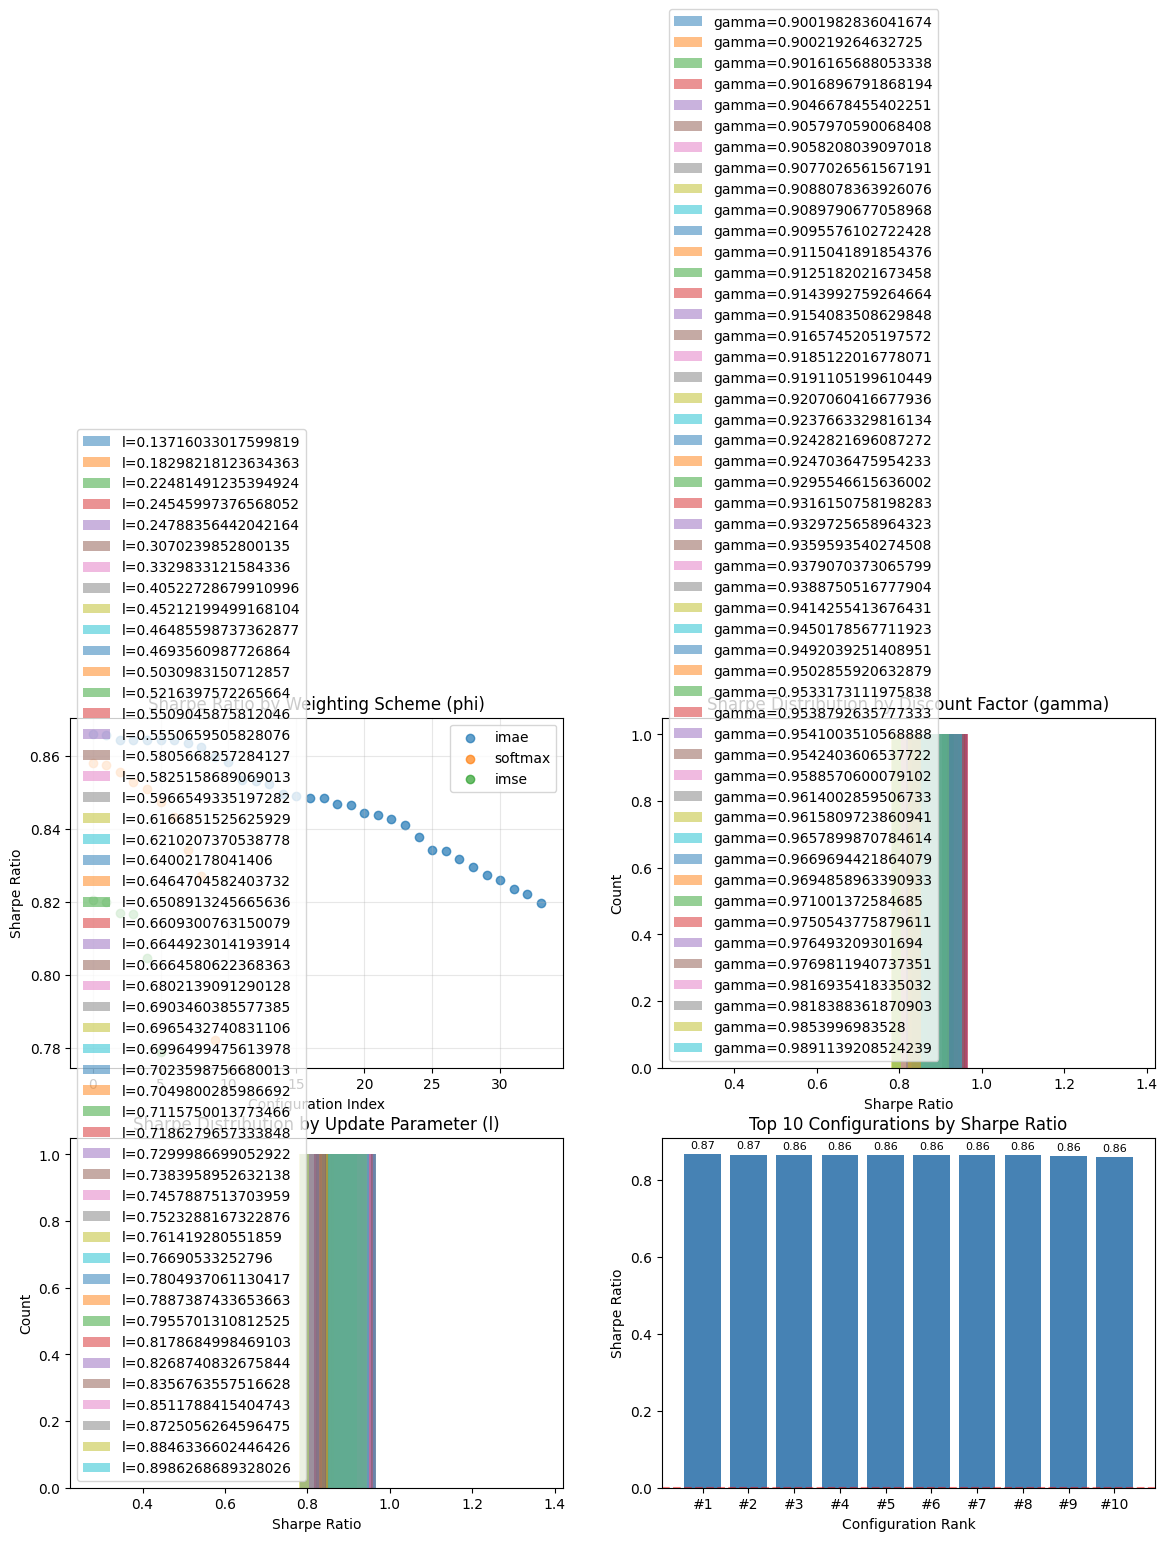


Visualization saved to results/hyperparameter_search_analysis.png


In [59]:
# ============================================================================
# Visualize Grid Search Results
# ============================================================================
import matplotlib.pyplot as plt

# Get results DataFrame
results_df = grid_search.get_results_df()

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sharpe by weighting scheme (phi)
ax1 = axes[0, 0]
for phi in results_df['phi'].unique():
    subset = results_df[results_df['phi'] == phi]
    ax1.scatter(range(len(subset)), subset['sharpe'].values, label=phi, alpha=0.7)
ax1.set_xlabel('Configuration Index')
ax1.set_ylabel('Sharpe Ratio')
ax1.set_title('Sharpe Ratio by Weighting Scheme (phi)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Sharpe vs gamma (discount factor)
ax2 = axes[0, 1]
for gamma in sorted(results_df['gamma'].unique()):
    subset = results_df[results_df['gamma'] == gamma]
    ax2.hist(subset['sharpe'], bins=10, alpha=0.5, label=f'gamma={gamma}')
ax2.set_xlabel('Sharpe Ratio')
ax2.set_ylabel('Count')
ax2.set_title('Sharpe Distribution by Discount Factor (gamma)')
ax2.legend()

# 3. Sharpe vs l (update parameter)
ax3 = axes[1, 0]
for l_val in sorted(results_df['l'].unique()):
    subset = results_df[results_df['l'] == l_val]
    ax3.hist(subset['sharpe'], bins=10, alpha=0.5, label=f'l={l_val}')
ax3.set_xlabel('Sharpe Ratio')
ax3.set_ylabel('Count')
ax3.set_title('Sharpe Distribution by Update Parameter (l)')
ax3.legend()

# 4. Top configurations bar chart
ax4 = axes[1, 1]
top_n = min(10, len(results_df))
top_results = results_df.nlargest(top_n, 'sharpe')
config_labels = [f"#{i+1}" for i in range(top_n)]
bars = ax4.bar(config_labels, top_results['sharpe'].values, color='steelblue')
ax4.set_xlabel('Configuration Rank')
ax4.set_ylabel('Sharpe Ratio')
ax4.set_title(f'Top {top_n} Configurations by Sharpe Ratio')
ax4.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# Add value labels on bars
for bar, val in zip(bars, top_results['sharpe'].values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('results/hyperparameter_search_analysis.png', dpi=150)
plt.show()

print("\nVisualization saved to results/hyperparameter_search_analysis.png")

In [90]:
# ============================================================================
# FINAL BACKTEST: Run Ensemble on TRADE Period
# ============================================================================
# Use the best parameters found during gridsearch on TEST period
# Now run the ensemble strategy on the unseen TRADE period for final evaluation

print("=" * 60)
print("FINAL BACKTEST: Running on TRADE Period")
print(f"Period: {TRADE_START_DATE} to {TRADE_END_DATE}")
print("=" * 60)

df_account_value, weights_history = ensemble_agent_bayesian.run_ensemble_with_params(
    params=best_params,
    data_period=(TRADE_START_DATE, TRADE_END_DATE)
)

# Calculate performance metrics
sharpe_trade = (252**0.5) * df_account_value.account_value.pct_change(1).mean() / df_account_value.account_value.pct_change(1).std()
total_return_trade = (df_account_value.account_value.iloc[-1] / df_account_value.account_value.iloc[0] - 1) * 100

print(f"Final Backtest Results (TRADE period):")
print(f"  Sharpe Ratio: {sharpe_trade:.4f}")
print(f"  Total Return: {total_return_trade:.2f}%")
print("=" * 60)

FINAL BACKTEST: Running on TRADE Period
Period: 2024-03-01 to 2026-03-01
Running ensemble with params: {'i_c': 2, 'e_w': 5, 'phi': 'imae', 'gamma': 0.9750543775879611, 'l': 0.7023598756680013}
Period: 2024-03-01 to 2026-03-01

Ensemble Results:
  Total Return: 39.11%
  Sharpe Ratio: 1.0390
Final Backtest Results (TRADE period):
  Sharpe Ratio: 1.0390
  Total Return: 39.11%


In [91]:
# ============================================================================
# BACKTEST INDIVIDUAL MODELS on TRADE Period
# ============================================================================
# Run each model separately on the TRADE period for comparison with ensemble

print("=" * 60)
print("BACKTESTING INDIVIDUAL MODELS ON TRADE PERIOD")
print(f"Period: {TRADE_START_DATE} to {TRADE_END_DATE}")
print("=" * 60)

individual_model_results = ensemble_agent_bayesian.backtest_individual_models(
    data_period=(TRADE_START_DATE, TRADE_END_DATE)
)

# Print summary
print("" + "=" * 60)
print("INDIVIDUAL MODEL BACKTESTING SUMMARY")
print("=" * 60)
for model_name, df_model in individual_model_results.items():
    total_return = (df_model["account_value"].iloc[-1] / df_model["account_value"].iloc[0] - 1) * 100
    daily_returns = df_model["account_value"].pct_change().dropna()
    sharpe = (252 ** 0.5) * daily_returns.mean() / (daily_returns.std() + 1e-8)
    print(f"{model_name.upper():6s}: Return={total_return:7.2f}%, Sharpe={sharpe:.4f}")


BACKTESTING INDIVIDUAL MODELS ON TRADE PERIOD
Period: 2024-03-01 to 2026-03-01
BACKTESTING INDIVIDUAL MODELS
Period: 2024-03-01 to 2026-03-01
Backtesting A2C...
  Total Return: 35.13%
  Sharpe Ratio: 1.1706
Backtesting PPO...
  Total Return: 38.04%
  Sharpe Ratio: 1.0618
Backtesting DDPG...
  Total Return: 25.03%
  Sharpe Ratio: 0.8828
Backtesting SAC...
  Total Return: 16.29%
  Sharpe Ratio: 0.5951
Backtesting TD3...
  Total Return: 40.85%
  Sharpe Ratio: 1.1685
Individual backtesting complete for 5 models.
INDIVIDUAL MODEL BACKTESTING SUMMARY
A2C   : Return=  35.13%, Sharpe=1.1706
PPO   : Return=  38.04%, Sharpe=1.0618
DDPG  : Return=  25.03%, Sharpe=0.8828
SAC   : Return=  16.29%, Sharpe=0.5951
TD3   : Return=  40.85%, Sharpe=1.1685


In [92]:
# ============================================================================
# BUY AND HOLD STRATEGY
# ============================================================================
# Buy each stock in equal notional amounts at the start of TRADE period
# and hold until the end

print("=" * 60)
print("COMPUTING BUY AND HOLD STRATEGY")
print(f"Period: {TRADE_START_DATE} to {TRADE_END_DATE}")
print("=" * 60)

# Get trade period data
trade_data = data_split(processed, start=TRADE_START_DATE, end=TRADE_END_DATE)
unique_dates = sorted(trade_data.date.unique())
unique_tickers = sorted(trade_data.tic.unique())

print(f"Number of trading days: {len(unique_dates)}")
print(f"Number of stocks: {len(unique_tickers)}")

# Get initial prices (first day of trade period)
first_day_data = trade_data[trade_data.date == unique_dates[0]].set_index('tic')

# Equal allocation to each stock
initial_amount = env_kwargs_dynamic["initial_amount"]
amount_per_stock = initial_amount / len(unique_tickers)

# Calculate number of shares to buy for each stock (fractional shares allowed)
shares_held = {}
for ticker in unique_tickers:
    if ticker in first_day_data.index:
        price = first_day_data.loc[ticker, 'close']
        shares_held[ticker] = amount_per_stock / price
    else:
        shares_held[ticker] = 0

print(f"Initial investment: ${initial_amount:,.2f}")
print(f"Amount per stock: ${amount_per_stock:,.2f}")

# Track portfolio value over time
buy_hold_values = []

for date in unique_dates:
    day_data = trade_data[trade_data.date == date].set_index('tic')
    
    # Calculate portfolio value
    portfolio_value = 0
    for ticker, shares in shares_held.items():
        if ticker in day_data.index:
            price = day_data.loc[ticker, 'close']
            portfolio_value += shares * price
    
    buy_hold_values.append({
        'date': date,
        'account_value': portfolio_value
    })

df_buy_hold = pd.DataFrame(buy_hold_values)

# Calculate metrics
total_return_bh = (df_buy_hold['account_value'].iloc[-1] / df_buy_hold['account_value'].iloc[0] - 1) * 100
daily_returns_bh = df_buy_hold['account_value'].pct_change().dropna()
sharpe_bh = (252 ** 0.5) * daily_returns_bh.mean() / (daily_returns_bh.std() + 1e-8)

print(f"Buy & Hold Results:")
print(f"  Initial Value: ${df_buy_hold['account_value'].iloc[0]:,.2f}")
print(f"  Final Value:   ${df_buy_hold['account_value'].iloc[-1]:,.2f}")
print(f"  Total Return:  {total_return_bh:.2f}%")
print(f"  Sharpe Ratio:  {sharpe_bh:.4f}")
print("=" * 60)


COMPUTING BUY AND HOLD STRATEGY
Period: 2024-03-01 to 2026-03-01
Number of trading days: 500
Number of stocks: 28
Initial investment: $1,000,000.00
Amount per stock: $35,714.29
Buy & Hold Results:
  Initial Value: $1,000,000.00
  Final Value:   $1,371,752.92
  Total Return:  37.18%
  Sharpe Ratio:  1.2279


In [94]:
# ============================================================================
# BACKTEST STATS FOR ALL STRATEGIES
# ============================================================================
from finrl.plot import backtest_stats

print("=" * 80)
print("DETAILED BACKTEST STATISTICS FOR ALL STRATEGIES")
print("=" * 80)

# Store all stats for comparison
all_model_stats = {}

# Get stats for each individual model
for model_name, df_model in individual_model_results.items():
    print(f"{'='*40}")
    print(f"  {model_name.upper()} BACKTEST STATS")
    print(f"{'='*40}")
    
    try:
        stats = backtest_stats(account_value=df_model)
        all_model_stats[model_name] = stats
        print(stats)
    except Exception as e:
        print(f"Error computing stats for {model_name}: {e}")

# Get stats for ensemble
print(f"{'='*40}")
print(f"  ENSEMBLE BACKTEST STATS")
print(f"{'='*40}")
try:
    ensemble_stats = backtest_stats(account_value=df_account_value)
    all_model_stats['ensemble'] = ensemble_stats
    print(ensemble_stats)
except Exception as e:
    print(f"Error computing ensemble stats: {e}")

# Get stats for buy-and-hold
print(f"{'='*40}")
print(f"  BUY & HOLD BACKTEST STATS")
print(f"{'='*40}")
try:
    buy_hold_stats = backtest_stats(account_value=df_buy_hold)
    all_model_stats['buy_hold'] = buy_hold_stats
    print(buy_hold_stats)
except Exception as e:
    print(f"Error computing buy & hold stats: {e}")

# Create comparison table
print("" + "=" * 80)
print("COMPARISON TABLE: KEY METRICS")
print("=" * 80)

comparison_metrics = ['Annual return', 'Cumulative returns', 'Annual volatility', 
                      'Sharpe ratio', 'Calmar ratio', 'Max drawdown', 'Sortino ratio']

# Build comparison DataFrame
comparison_data = {}
for model_name, stats in all_model_stats.items():
    display_name = model_name.upper() if model_name != 'buy_hold' else 'BUY&HOLD'
    comparison_data[display_name] = {}
    for metric in comparison_metrics:
        if metric in stats.index:
            comparison_data[display_name][metric] = stats[metric]

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string())

# Save comparison to CSV
comparison_df.to_csv('model_comparison_stats.csv')
print("Comparison stats saved to model_comparison_stats.csv")


DETAILED BACKTEST STATISTICS FOR ALL STRATEGIES
  A2C BACKTEST STATS
Annual return          0.163870
Cumulative returns     0.351335
Annual volatility      0.138055
Sharpe ratio           1.170562
Calmar ratio           1.194609
Stability              0.714202
Max drawdown          -0.137175
Omega ratio            1.233170
Sortino ratio          1.741220
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.059027
Daily value at risk   -0.016752
dtype: float64
Annual return          0.163870
Cumulative returns     0.351335
Annual volatility      0.138055
Sharpe ratio           1.170562
Calmar ratio           1.194609
Stability              0.714202
Max drawdown          -0.137175
Omega ratio            1.233170
Sortino ratio          1.741220
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.059027
Daily value at risk   -0.016752
dtype: float64
  PPO BACKTEST STATS
Annual return          0.176407
Cumulative retur

<a id='6'></a>
# Part 7: Backtest Our Strategy on TRADE Period
Backtesting plays a key role in evaluating the performance of a trading strategy. The final backtest is performed on the **TRADE period** (unseen data) using the best hyperparameters found during grid search on the TEST period.

- **TRAIN period**: RL agents are trained
- **TEST period**: Grid search to find optimal ensemble hyperparameters  
- **TRADE period**: Final out-of-sample backtest to evaluate true performance

In [95]:
unique_trade_date = processed[(processed.date > TRADE_START_DATE)&(processed.date <= TRADE_END_DATE)].date.unique()

<a id='6.1'></a>
## 7.1 BackTestStats
pass in df_account_value, this information is stored in env class


In [96]:
print("==============Get Backtest Results===========")
now = datetime.datetime.now().strftime('%Y%m%d-%Hh%M')

perf_stats_all = backtest_stats(account_value=df_account_value)
perf_stats_all = pd.DataFrame(perf_stats_all)

==============Get Backtest Results===========
Annual return          0.181010
Cumulative returns     0.391106
Annual volatility      0.175227
Sharpe ratio           1.038997
Calmar ratio           1.404260
Stability              0.567508
Max drawdown          -0.128901
Omega ratio            1.200831
Sortino ratio          1.572827
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.078568
Daily value at risk   -0.021354
dtype: float64


In [97]:
#baseline stats
print("==============Get Baseline Stats===========")
df_dji_ = get_baseline(
        ticker="^DJI",
        start = df_account_value.loc[0,'date'],
        end = df_account_value.loc[len(df_account_value)-1,'date'])

stats = backtest_stats(df_dji_, value_col_name = 'close')

[*********************100%***********************]  1 of 1 completed

==============Get Baseline Stats===========
Shape of DataFrame:  (499, 8)
Annual return          0.126665
Cumulative returns     0.266373
Annual volatility      0.145783
Sharpe ratio           0.892403
Calmar ratio           0.773797
Stability              0.794279
Max drawdown          -0.163692
Omega ratio            1.177785
Sortino ratio          1.324330
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.925272
Daily value at risk   -0.017851
dtype: float64


In [98]:
df_dji = pd.DataFrame()
df_dji['date'] = df_account_value['date']
df_dji['dji'] = df_dji_['close'] / df_dji_['close'][0] * env_kwargs_dynamic["initial_amount"]
print("df_dji: ", df_dji)
df_dji.to_csv("df_dji.csv")
df_dji = df_dji.set_index(df_dji.columns[0])
print("df_dji: ", df_dji)
df_dji.to_csv("df_dji+.csv")

df_account_value.to_csv('df_account_value.csv')


df_dji:             date           dji
0    2024-03-01  1.000000e+06
1    2024-03-04  9.975043e+05
2    2024-03-05  9.871522e+05
3    2024-03-06  9.890929e+05
4    2024-03-07  9.924265e+05
..          ...           ...
495  2026-02-23  1.248589e+06
496  2026-02-24  1.258066e+06
497  2026-02-25  1.265937e+06
498  2026-02-26  1.266373e+06
499  2026-02-27           NaN

[500 rows x 2 columns]
df_dji:                       dji
date                    
2024-03-01  1.000000e+06
2024-03-04  9.975043e+05
2024-03-05  9.871522e+05
2024-03-06  9.890929e+05
2024-03-07  9.924265e+05
...                  ...
2026-02-23  1.248589e+06
2026-02-24  1.258066e+06
2026-02-25  1.265937e+06
2026-02-26  1.266373e+06
2026-02-27           NaN

[500 rows x 1 columns]


<a id='6.2'></a>
## 7.2 BackTestPlot

Building comparison dataframe...
  Added a2c: 500 rows
  Added ppo: 500 rows
  Added ddpg: 500 rows
  Added sac: 500 rows
  Added td3: 500 rows
  Added buy_hold: 500 rows
==============Compare to DJIA===========
result columns:  ['ensemble', 'a2c', 'ppo', 'ddpg', 'sac', 'td3', 'buy_hold', 'dji']
Final result shape:  (500, 8)
                  Ensemble             A2C             PPO            DDPG  \
date                                                                         
2024-03-01  1000000.000000  1000000.000000  1000000.000000  1000000.000000   
2024-03-04   999741.447373   999772.563731   999984.883636   999070.301076   
2024-03-05   999252.873980   998445.439288   999845.988495   997596.372240   
2024-03-06   999495.930303   999399.333293   999892.411624   997768.250064   
2024-03-07   999358.398603   999893.073977   999998.344560   996500.037338   

                       SAC           TD3      Buy & Hold             DJI  
date                                               

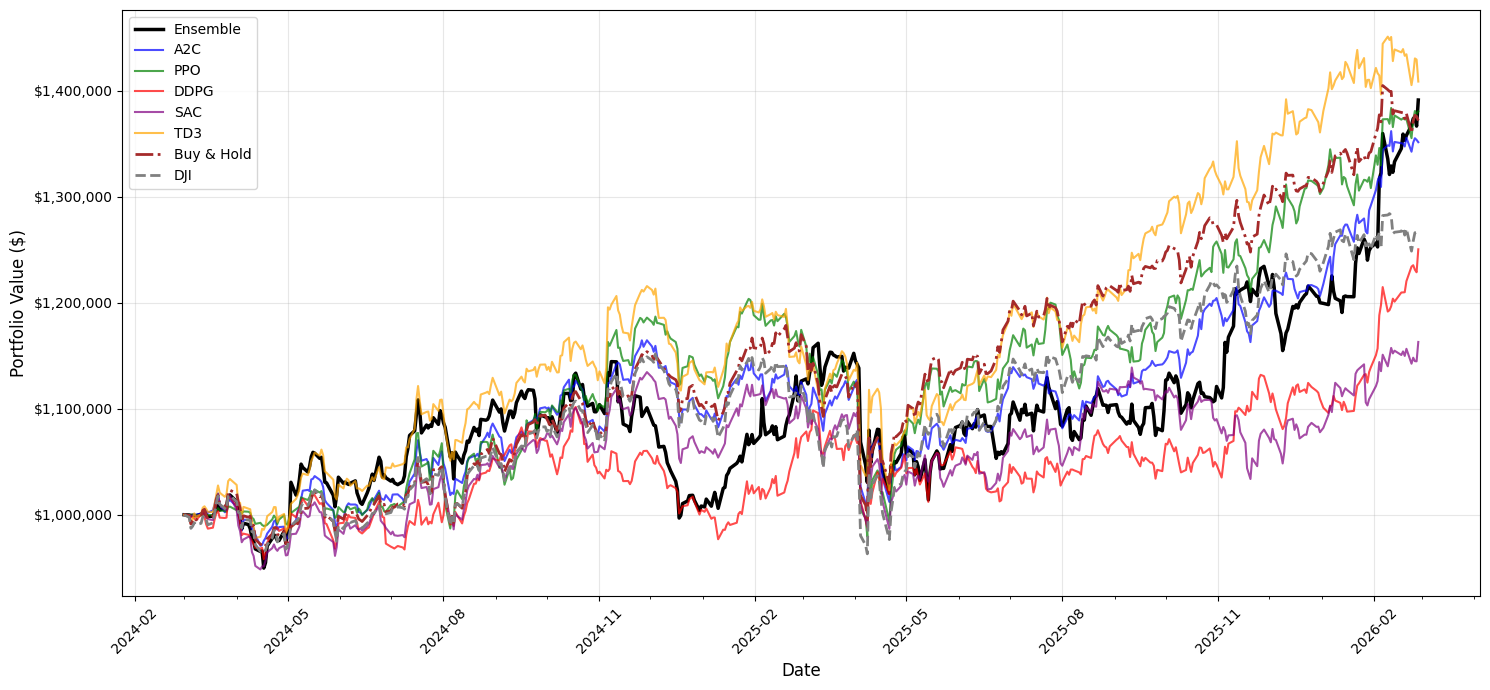

FINAL PERFORMANCE SUMMARY (TRADE Period)
Strategy         Final Value     Return     Sharpe
--------------------------------------------------
Ensemble     $    1,391,106     39.11%    1.0390
A2C          $    1,351,335     35.13%    1.1706
PPO          $    1,380,369     38.04%    1.0618
DDPG         $    1,250,324     25.03%    0.8828
SAC          $    1,162,938     16.29%    0.5951
TD3          $    1,408,512     40.85%    1.1685
Buy & Hold   $    1,371,753     37.18%    1.2279
DJI          $    1,266,373     26.64%    0.8915


In [101]:
# ============================================================================
# COMPARE ALL STRATEGIES
# ============================================================================
import matplotlib.dates as mdates

df.to_csv("df.csv")

# Create result dataframe with ensemble
df_result_ensemble = pd.DataFrame({
    'date': df_account_value['date'], 
    'ensemble': df_account_value['account_value']
})
df_result_ensemble = df_result_ensemble.set_index('date')

print("Building comparison dataframe...")

# Start building result with ensemble
result = df_result_ensemble.copy()

# Add individual model results
for model_name, df_model in individual_model_results.items():
    df_model_indexed = pd.DataFrame({
        'date': df_model['date'],
        model_name: df_model['account_value']
    })
    df_model_indexed = df_model_indexed.set_index('date')
    result = pd.merge(result, df_model_indexed, left_index=True, right_index=True, how='outer')
    print(f"  Added {model_name}: {len(df_model)} rows")

# Add buy-and-hold
df_buy_hold_indexed = pd.DataFrame({
    'date': df_buy_hold['date'],
    'buy_hold': df_buy_hold['account_value']
})
df_buy_hold_indexed = df_buy_hold_indexed.set_index('date')
result = pd.merge(result, df_buy_hold_indexed, left_index=True, right_index=True, how='outer')
print(f"  Added buy_hold: {len(df_buy_hold)} rows")

# Merge with DJI
print("==============Compare to DJIA===========")
result = pd.merge(result, df_dji, left_index=True, right_index=True, how='outer')
print("result columns: ", result.columns.tolist())
result.to_csv("result.csv")

# Rename columns for cleaner plot legend
column_rename = {col: col.upper() if col in ['a2c', 'ppo', 'ddpg', 'sac', 'td3'] else col for col in result.columns}
column_rename['ensemble'] = 'Ensemble'
column_rename['dji'] = 'DJI'
column_rename['buy_hold'] = 'Buy & Hold'
result = result.rename(columns=column_rename)

print("Final result shape: ", result.shape)
print(result.head())

# Plot all strategies
%matplotlib inline

fig, ax = plt.subplots(figsize=(15, 7))

# Define colors for each strategy
colors = {
    'Ensemble': 'black',
    'DJI': 'gray',
    'Buy & Hold': 'brown',
    'A2C': 'blue',
    'PPO': 'green',
    'DDPG': 'red',
    'SAC': 'purple',
    'TD3': 'orange'
}

# Convert index to datetime for proper x-axis formatting
result.index = pd.to_datetime(result.index)

# Plot each column with specific color and style
for col in result.columns:
    if col in colors:
        if col == 'Ensemble':
            ax.plot(result.index, result[col], label=col, color=colors[col], linewidth=2.5, linestyle='-')
        elif col == 'DJI':
            ax.plot(result.index, result[col], label=col, color=colors[col], linewidth=2, linestyle='--')
        elif col == 'Buy & Hold':
            ax.plot(result.index, result[col], label=col, color=colors[col], linewidth=2, linestyle='-.')
        else:
            ax.plot(result.index, result[col], label=col, color=colors[col], linewidth=1.5, alpha=0.7)
    else:
        ax.plot(result.index, result[col], label=col, linewidth=1.5, alpha=0.7)

# Fix x-axis: fewer date ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Every 3 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())  # Minor ticks every month

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value ($)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Format y-axis with dollar signs and commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final performance summary
print("" + "=" * 80)
print("FINAL PERFORMANCE SUMMARY (TRADE Period)")
print("=" * 80)
print(f"{'Strategy':<12} {'Final Value':>15} {'Return':>10} {'Sharpe':>10}")
print("-" * 50)
for col in result.columns:
    if col not in ['date']:
        initial = result[col].dropna().iloc[0]
        final = result[col].dropna().iloc[-1]
        total_return = (final / initial - 1) * 100
        daily_returns = result[col].pct_change().dropna()
        sharpe = (252 ** 0.5) * daily_returns.mean() / (daily_returns.std() + 1e-8)
        print(f"{col:<12} ${final:>13,.0f} {total_return:>9.2f}% {sharpe:>9.4f}")
